In [6]:
# Generelle moduler og funksjonsbeskrivelser brukt i forelesningen
from numpy import sin, cos, pi, exp, angle, abs, unwrap, log10
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [8.00, 4.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.xmargin"] = 0.0

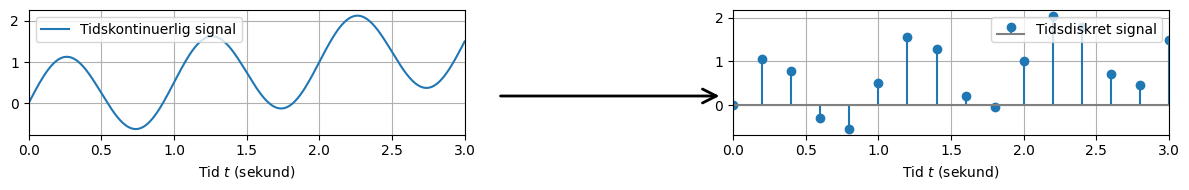

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def x(t):
    return t/2 + np.sin(np.pi*2*t)


t = np.linspace(0, 3, 501)
fs = 5
t_n = np.arange(0, 3+1/fs, 1/fs)



from matplotlib.patches import FancyArrowPatch

plt.figure(figsize=(12,2))
fig = plt.gcf()
ax_left = plt.subplot(1,5,(1,2))
ax_right = plt.subplot(1,5,(4,5))

# (replot content since we redefined axes)
ax_left.plot(t, x(t), label="Tidskontinuerlig signal")
ax_left.set_xlabel("Tid $t$ (sekund)")
ax_left.legend()
ax_right.stem(t_n, x(t_n), basefmt="grey", label="Tidsdiskret signal")
ax_right.legend()
ax_right.set_xlabel("Tid $t$ (sekund)")

# Get axis positions in figure coordinates
bbox_left = ax_left.get_position()
bbox_right = ax_right.get_position()

# Arrow start and end points (center-right → center-left)
start = (bbox_left.x1, bbox_left.y0 + bbox_left.height/2)
end   = (bbox_right.x0, bbox_right.y0 + bbox_right.height/2)

# Create arrow
arrow = FancyArrowPatch(
    start, end,
    transform=fig.transFigure,
    arrowstyle="->",
    linewidth=2,
    color="black",
        mutation_scale=25   # ⬅ increases arrow head size
)

fig.patches.append(arrow)
plt.savefig("discretized_signal.svg")

# Block Diagrams

In [20]:
%load_ext jupyter_tikz

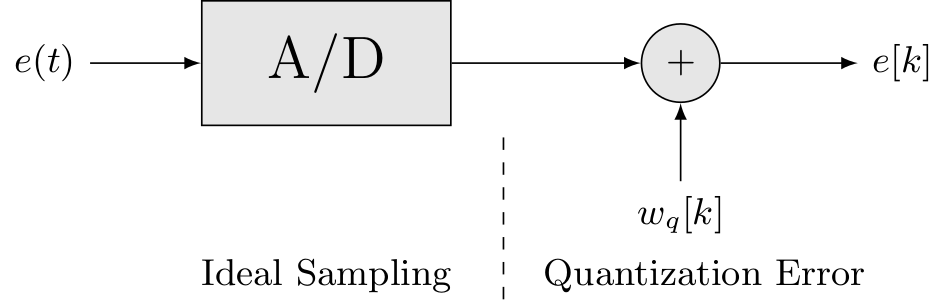

In [2]:
%%tikz -p=\include{prefix.tex} --dpi=300 -r -S quantization_model.png
\begin{tikzpicture}[auto, node distance=2cm]
    \node [input, name=input] {};
    \node [block, right of=input,yshift=0cm] (system){\Large A/D};
    \node [sum,right of=system, xshift=2cm] (sum){$+$};
    \node [input, below of=sum,yshift=1cm] (noise) {};
    \node [output, right of=sum, xshift=-0.5cm] (output) {};
    
    \draw [-latex] (input) node[left]{$e(t)$}  -- (system);
    \draw [-latex] (system)  -- (sum);
    \draw [-latex] (sum)  -- (output) node[right]{$e[k]$};
    \draw [-latex] (noise) node[below]{$w_q[k]$} -- (sum);

    \draw [draw, dashed] (3.5, -2.0) -- (3.5, -.55);
    \node at (2, -1.8) {Ideal Sampling};
    \node at (5.2, -1.8) {Quantization Error};

\end{tikzpicture}


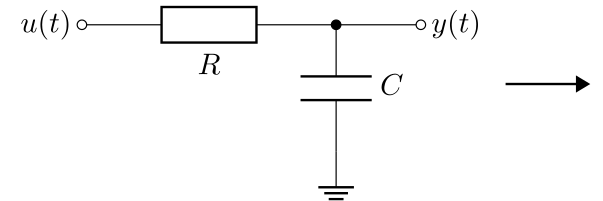

In [30]:
%%tikz -p=\include{preamble.tex} -sc=3 -S  rc_circuit.svg
\begin{tikzpicture}
    \draw
    (0,0) to[R=$R$,*-o] ++(-3,0) node[left]{$u(t)$}
    (0,0) to[short,-o] ++(1,0) node[right]{$y(t)$}
    (0,0) to[C=$C$,invert] ++(0,-1.5) node[ground]{}
    ;
    \draw[->, thick] (2,-0.7) -- (3,-0.7);
\end{tikzpicture}